In [6]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 

import warnings 
warnings.filterwarnings('ignore')

In [7]:
data = pd.read_csv('../data/indian_tech_jobs_2026_cleaned.csv')


In [3]:
data.shape

(23201, 23)

In [4]:
data.describe()

,company_rating,experience_min_yrs,experience_max_yrs,salary_min_lpa,salary_max_lpa,salary_midpoint_lpa,skills_count,days_since_posted
count,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000,23201.000000
mean,3.586449,4.135080,7.829059,1.383952,2.271790,1.827872,7.604198,15.698935
std,0.514250,2.933976,3.946834,4.841570,7.469383,6.109373,1.456530,7.575881
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.400000,2.000000,5.000000,0.000000,0.000000,0.000000,8.000000,7.000000
50%,3.600000,4.000000,8.000000,0.000000,0.000000,0.000000,8.000000,21.000000
75%,3.800000,6.000000,10.000000,0.000000,0.000000,0.000000,8.000000,21.000000
max,5.000000,25.000000,31.000000,85.000000,90.000000,87.500000,8.000000,90.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_title            23201 non-null  object 
 1   company_name         23201 non-null  object 
 2   company_rating       23201 non-null  float64
 3   location             23201 non-null  object 
 4   role_category        23201 non-null  object 
 5   experience_min_yrs   23201 non-null  float64
 6   experience_max_yrs   23201 non-null  float64
 7   salary_min_lpa       23201 non-null  float64
 8   salary_max_lpa       23201 non-null  float64
 9   salary_midpoint_lpa  23201 non-null  float64
 10  salary_disclosed     23201 non-null  bool   
 11  skills_required      23201 non-null  object 
 12  skills_count         23201 non-null  int64  
 13  work_mode            23201 non-null  object 
 14  company_size_bucket  23201 non-null  object 
 15  salary_tier          23201 non-null 

In [6]:
data.head(5)

,job_title,company_name,company_rating,location,role_category,experience_min_yrs,experience_max_yrs,salary_min_lpa,salary_max_lpa,salary_midpoint_lpa,...,work_mode,company_size_bucket,salary_tier,experience_tier,is_senior,primary_city,skill_domain,days_since_posted,is_fresher_friendly,salary_negotiable
0,Data Scientist,Cisco,4.1,Bengaluru,Data Scientist,7.0,10.0,0.0,0.0,0.0,...,On-Site,Large (1000+),Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,21.0,False,False
1,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Data Scientist,4.0,8.0,0.0,0.0,0.0,...,On-Site,Small/Startup (<100),Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,21.0,False,False
2,Analytics Data Scientist,Foreign It Consulting Mnc,3.6,"Hyderabad, Chennai, Bengaluru",Data Scientist,4.0,9.0,0.0,0.0,0.0,...,On-Site,Large (1000+),Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,21.0,False,False
3,Data Scientist,Fortune 500 It Services Company,3.6,"Mumbai, Bengaluru",Data Scientist,0.0,0.0,0.0,0.0,0.0,...,On-Site,Small/Startup (<100),Undisclosed,Fresher,False,Mumbai,Data Science,21.0,True,False
4,Sr. Artificial Intelligence Engineer,Fortune 500 Product-Based Mnc,3.6,"Pune, Bengaluru",Data Scientist,5.0,10.0,0.0,0.0,0.0,...,On-Site,Small/Startup (<100),Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,21.0,False,False


In [7]:
data.dtypes

job_title               object
company_name            object
company_rating         float64
location                object
role_category           object
experience_min_yrs     float64
experience_max_yrs     float64
salary_min_lpa         float64
salary_max_lpa         float64
salary_midpoint_lpa    float64
salary_disclosed          bool
skills_required         object
skills_count             int64
work_mode               object
company_size_bucket     object
salary_tier             object
experience_tier         object
is_senior                 bool
primary_city            object
skill_domain            object
days_since_posted      float64
is_fresher_friendly       bool
salary_negotiable         bool
dtype: object

In [8]:
data.columns

Index(['job_title', 'company_name', 'company_rating', 'location',
       'role_category', 'experience_min_yrs', 'experience_max_yrs',
       'salary_min_lpa', 'salary_max_lpa', 'salary_midpoint_lpa',
       'salary_disclosed', 'skills_required', 'skills_count', 'work_mode',
       'company_size_bucket', 'salary_tier', 'experience_tier', 'is_senior',
       'primary_city', 'skill_domain', 'days_since_posted',
       'is_fresher_friendly', 'salary_negotiable'],
      dtype='object')

In [9]:
categorical_columns = [
    "role_category",
    "work_mode",
    "company_size_bucket",
    "salary_tier",
    "experience_tier",
    "primary_city",
    "skill_domain"
]

for col in categorical_columns:
    data[col]=data[col].astype("category")

data.head(5)



,job_title,company_name,company_rating,location,role_category,experience_min_yrs,experience_max_yrs,salary_min_lpa,salary_max_lpa,salary_midpoint_lpa,...,work_mode,company_size_bucket,salary_tier,experience_tier,is_senior,primary_city,skill_domain,days_since_posted,is_fresher_friendly,salary_negotiable
0,Data Scientist,Cisco,4.1,Bengaluru,Data Scientist,7.0,10.0,0.0,0.0,0.0,...,On-Site,Large (1000+),Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,21.0,False,False
1,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Data Scientist,4.0,8.0,0.0,0.0,0.0,...,On-Site,Small/Startup (<100),Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,21.0,False,False
2,Analytics Data Scientist,Foreign It Consulting Mnc,3.6,"Hyderabad, Chennai, Bengaluru",Data Scientist,4.0,9.0,0.0,0.0,0.0,...,On-Site,Large (1000+),Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,21.0,False,False
3,Data Scientist,Fortune 500 It Services Company,3.6,"Mumbai, Bengaluru",Data Scientist,0.0,0.0,0.0,0.0,0.0,...,On-Site,Small/Startup (<100),Undisclosed,Fresher,False,Mumbai,Data Science,21.0,True,False
4,Sr. Artificial Intelligence Engineer,Fortune 500 Product-Based Mnc,3.6,"Pune, Bengaluru",Data Scientist,5.0,10.0,0.0,0.0,0.0,...,On-Site,Small/Startup (<100),Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,21.0,False,False


In [10]:

data['role_category'].unique()

['Data Scientist', 'Data Analyst', 'Machine Learning Engineer', 'Data Engineer', 'Business Analyst', 'Python Developer']
Categories (6, object): ['Business Analyst', 'Data Analyst', 'Data Engineer', 'Data Scientist', 'Machine Learning Engineer', 'Python Developer']

In [11]:
print(data["salary_tier"].unique())
print(data["experience_tier"].unique())

['Undisclosed', 'Senior (10-20 LPA)', 'Leadership (20+ LPA)', 'Mid (6-10 LPA)', 'Junior (3-6 LPA)', 'Entry (<3 LPA)']
Categories (6, object): ['Entry (<3 LPA)', 'Junior (3-6 LPA)', 'Leadership (20+ LPA)', 'Mid (6-10 LPA)', 'Senior (10-20 LPA)', 'Undisclosed']
['Senior (6-8 Yrs)', 'Mid (3-5 Yrs)', 'Fresher', 'Junior (0-2 Yrs)', 'Lead/Architect (9+ Yrs)']
Categories (5, object): ['Fresher', 'Junior (0-2 Yrs)', 'Lead/Architect (9+ Yrs)', 'Mid (3-5 Yrs)', 'Senior (6-8 Yrs)']


In [12]:
from sklearn.preprocessing import LabelEncoder

# Columns to encode
label_columns = [
    "salary_tier",
    "experience_tier"
]

le = LabelEncoder()

for col in label_columns:
    data[col] = le.fit_transform(data[col])

# One-Hot Encoding
data = pd.get_dummies(
    data,
    columns=[
        "role_category",
        "work_mode",
        "company_size_bucket",
        "skill_domain"
    ],
    drop_first=True
)



In [13]:
data

,job_title,company_name,company_rating,location,experience_min_yrs,experience_max_yrs,salary_min_lpa,salary_max_lpa,salary_midpoint_lpa,salary_disclosed,...,role_category_Machine Learning Engineer,role_category_Python Developer,work_mode_On-Site,work_mode_Remote,company_size_bucket_Mid (100-999),company_size_bucket_Small/Startup (<100),skill_domain_Business Intelligence,skill_domain_Cloud & DevOps,skill_domain_Data Engineering,skill_domain_Data Science
0,Data Scientist,Cisco,4.1,Bengaluru,7.0,10.0,0.0,0.0,0.0,False,...,False,False,True,False,False,False,True,False,False,False
1,Data Scientist,Caterpillar Inc,4.1,Bengaluru,4.0,8.0,0.0,0.0,0.0,False,...,False,False,True,False,False,True,False,False,False,False
2,Analytics Data Scientist,Foreign It Consulting Mnc,3.6,"Hyderabad, Chennai, Bengaluru",4.0,9.0,0.0,0.0,0.0,False,...,False,False,True,False,False,False,True,False,False,False
3,Data Scientist,Fortune 500 It Services Company,3.6,"Mumbai, Bengaluru",0.0,0.0,0.0,0.0,0.0,False,...,False,False,True,False,False,True,False,False,False,True
4,Sr. Artificial Intelligence Engineer,Fortune 500 Product-Based Mnc,3.6,"Pune, Bengaluru",5.0,10.0,0.0,0.0,0.0,False,...,False,False,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23196,Python Developer-Hyderabad,Infosys,3.5,Hybrid - Hyderabad,2.0,7.0,0.0,0.0,0.0,False,...,False,True,False,False,False,False,False,False,False,True
23197,Python Developer,Accufy,3.6,Hyderabad,0.0,4.0,0.0,0.0,0.0,False,...,False,True,True,False,False,True,False,False,False,True
23198,Walk in Interview Python Developer II Hyderabad,Tata Consultancy Services,3.3,"Hyderabad, Pune, Mumbai (All Areas)",13.0,8.0,0.0,0.0,0.0,False,...,False,True,True,False,False,False,False,False,True,False
23199,Python Developer,Mediamint,2.8,Hybrid - Hyderabad,3.0,5.0,0.0,0.0,0.0,False,...,False,True,False,False,False,True,False,False,False,True


In [14]:
numerical_columns = [
    'company_rating',
    'experience_min_yrs',
    'experience_max_yrs',
    'salary_min_lpa',
    'salary_max_lpa',
    'salary_midpoint_lpa',
    'skills_count',
    'days_since_posted'
]


In [15]:
for col in numerical_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    outliers = data[(data[col] < lower_limit) | (data[col] > upper_limit)]

    print(f"{col}")
    print(f"Lower Limit : {lower_limit:.2f}")
    print(f"Upper Limit : {upper_limit:.2f}")
    print(f"Number of Outliers : {len(outliers)}")
    print("-" * 50)

company_rating
Lower Limit : 2.80
Upper Limit : 4.40
Number of Outliers : 2685
--------------------------------------------------
experience_min_yrs
Lower Limit : -4.00
Upper Limit : 12.00
Number of Outliers : 414
--------------------------------------------------
experience_max_yrs
Lower Limit : -2.50
Upper Limit : 17.50
Number of Outliers : 533
--------------------------------------------------
salary_min_lpa
Lower Limit : 0.00
Upper Limit : 0.00
Number of Outliers : 2705
--------------------------------------------------
salary_max_lpa
Lower Limit : 0.00
Upper Limit : 0.00
Number of Outliers : 2766
--------------------------------------------------
salary_midpoint_lpa
Lower Limit : 0.00
Upper Limit : 0.00
Number of Outliers : 2766
--------------------------------------------------
skills_count
Lower Limit : 8.00
Upper Limit : 8.00
Number of Outliers : 2356
--------------------------------------------------
days_since_posted
Lower Limit : -14.00
Upper Limit : 42.00
Number of Outliers

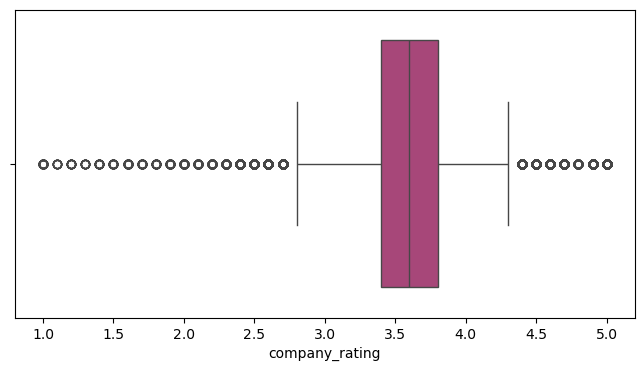

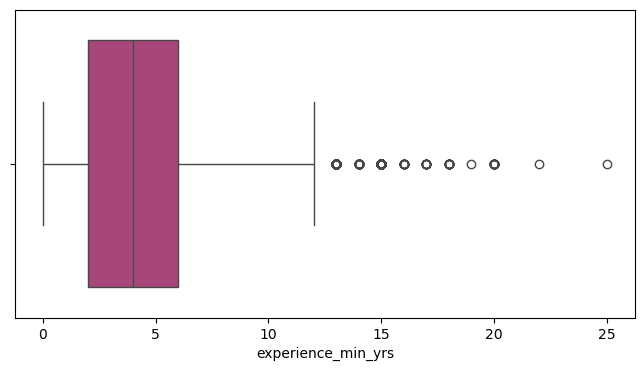

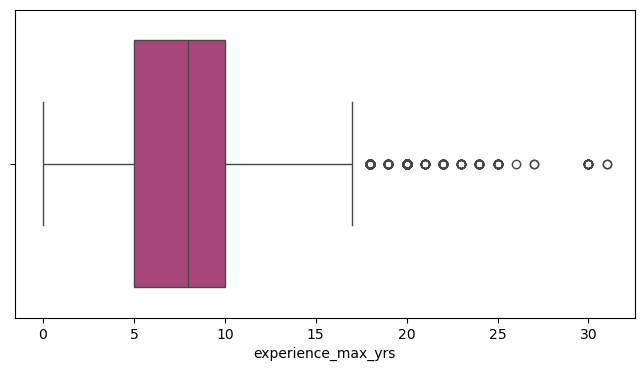

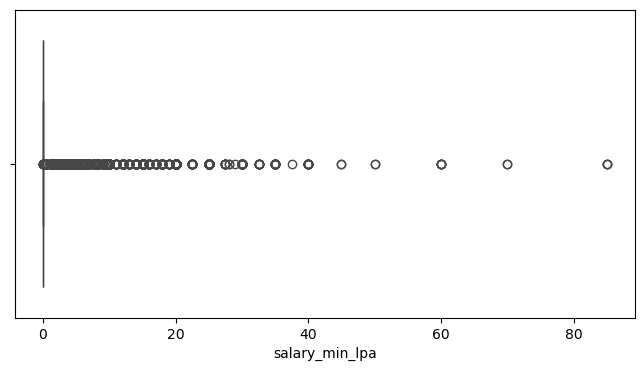

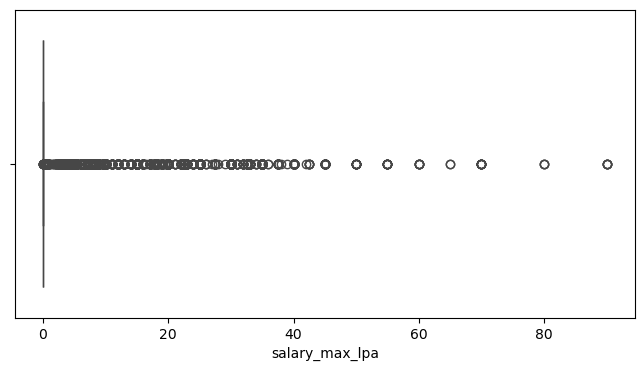

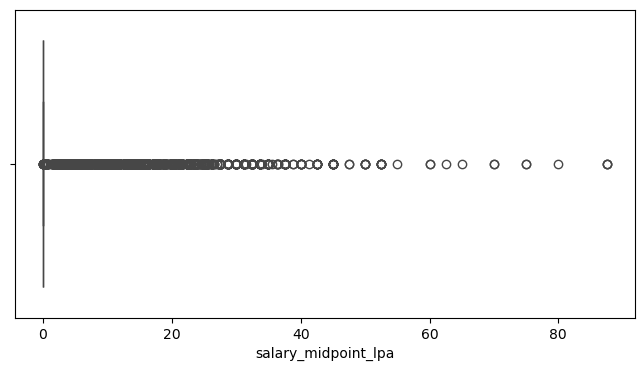

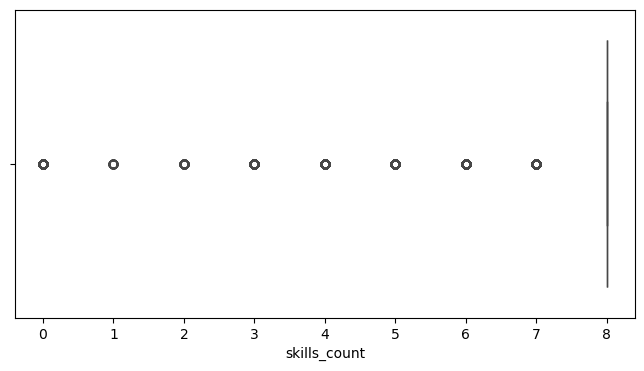

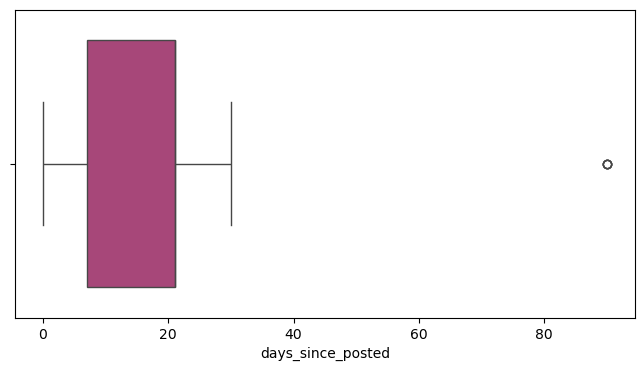

In [16]:
for i in numerical_columns: 
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[i],palette="magma")

<Axes: xlabel='company_rating', ylabel='Count'>

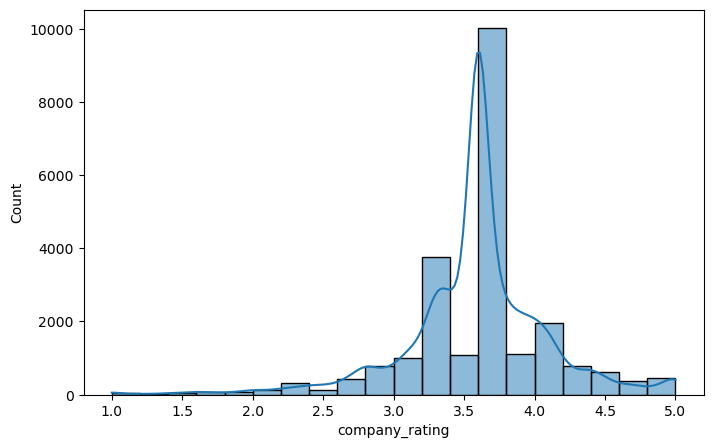

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(x=data['company_rating'],palette="rainbow",bins=20, kde=True)

<Axes: xlabel='salary_midpoint_lpa', ylabel='Count'>

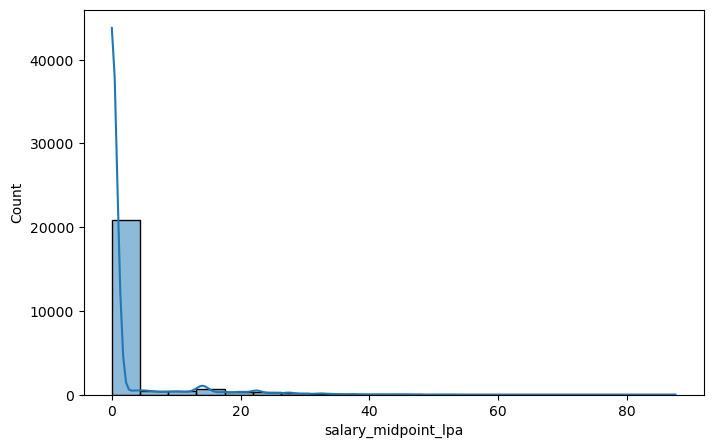

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(x=data['salary_midpoint_lpa'],palette="rainbow",bins=20, kde=True)

In [26]:
data.columns

Index(['job_title', 'company_name', 'company_rating', 'location',
       'role_category', 'experience_min_yrs', 'experience_max_yrs',
       'salary_min_lpa', 'salary_max_lpa', 'salary_midpoint_lpa',
       'salary_disclosed', 'skills_required', 'skills_count', 'work_mode',
       'company_size_bucket', 'salary_tier', 'experience_tier', 'is_senior',
       'primary_city', 'skill_domain', 'days_since_posted',
       'is_fresher_friendly', 'salary_negotiable'],
      dtype='object')

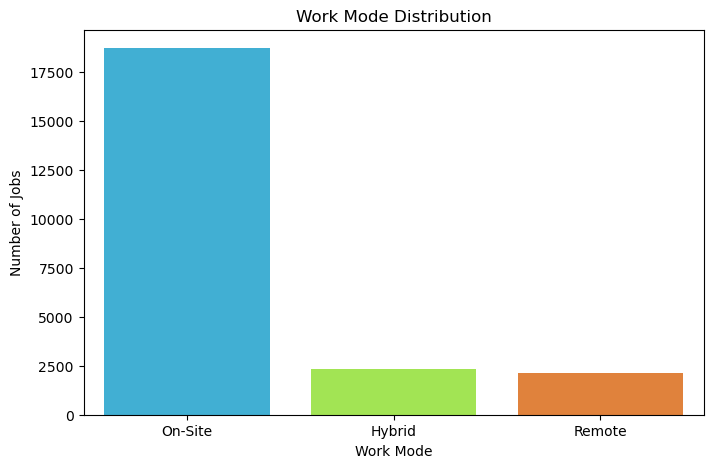

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="work_mode",
    hue="work_mode",
    palette="turbo",
    legend=False
)

plt.title("Work Mode Distribution")
plt.xlabel("Work Mode")
plt.ylabel("Number of Jobs")
plt.show()




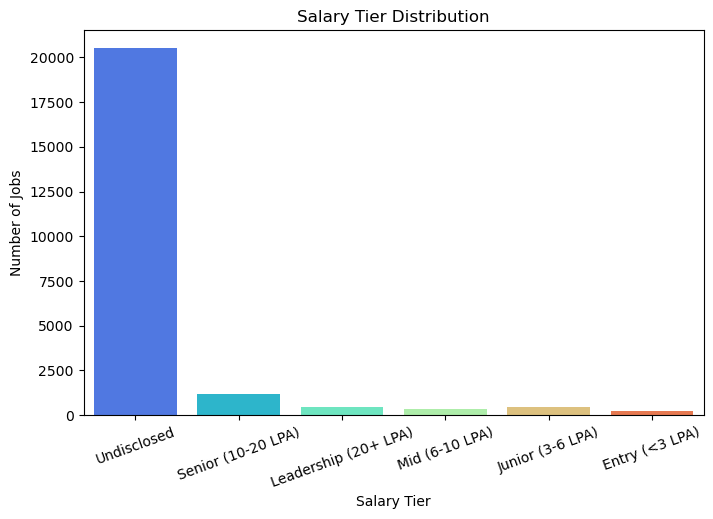

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="salary_tier",
    hue="salary_tier",
    palette="rainbow",
    legend=False
)

plt.title("Salary Tier Distribution")
plt.xlabel("Salary Tier")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=20)
plt.show()

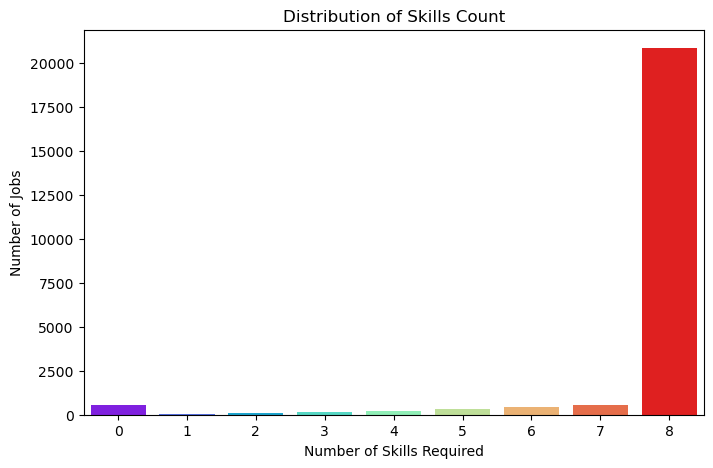

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="skills_count",
    hue="skills_count",
    palette="rainbow",
    legend=False
)

plt.title("Distribution of Skills Count")
plt.xlabel("Number of Skills Required")
plt.ylabel("Number of Jobs")
plt.show()


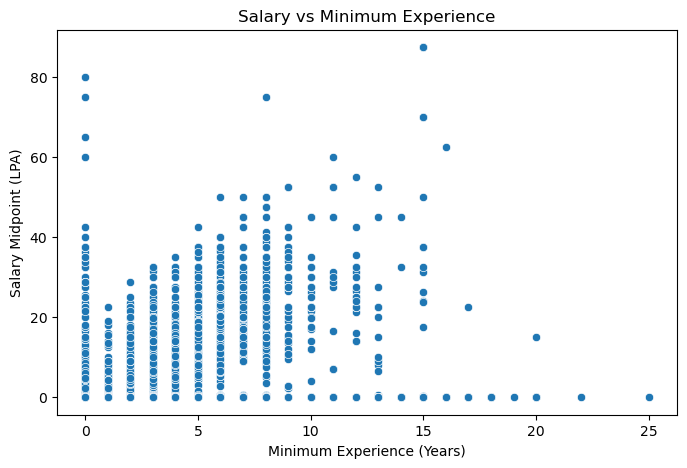

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=data,
    x="experience_min_yrs",
    y="salary_midpoint_lpa"
)
plt.title("Salary vs Minimum Experience")
plt.xlabel("Minimum Experience (Years)")
plt.ylabel("Salary Midpoint (LPA)")
plt.show()

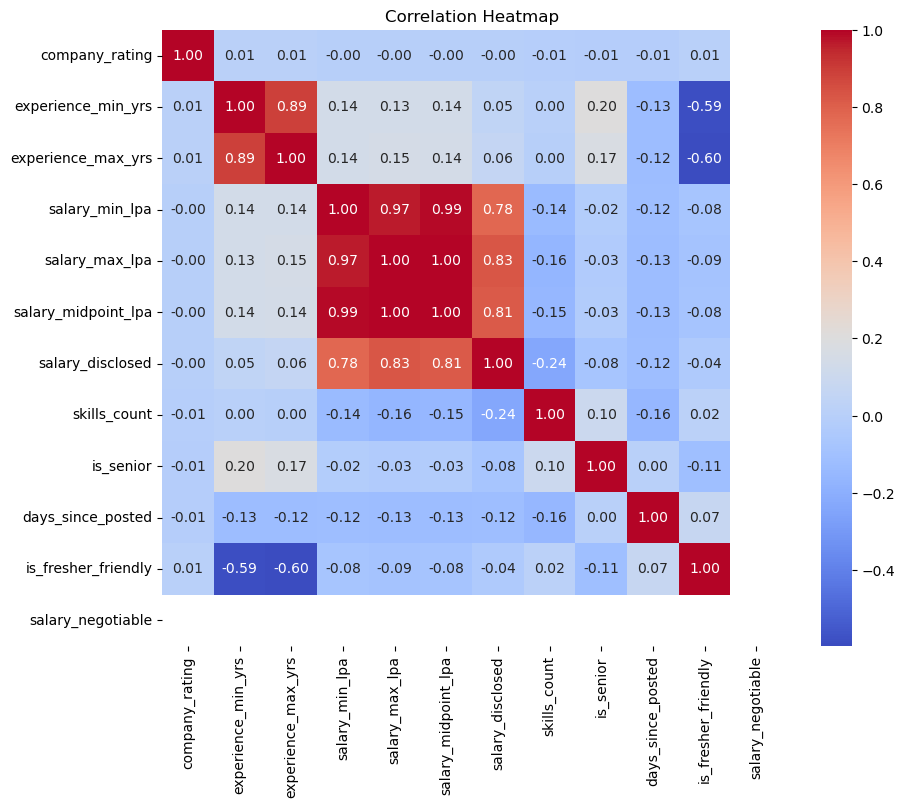

In [16]:
plt.figure(figsize=(10,8))

numeric_data = data.select_dtypes(include=["int64", "float64", "bool"])

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()